Number of rows: 569
Number of columns: 32
Number of missing values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error

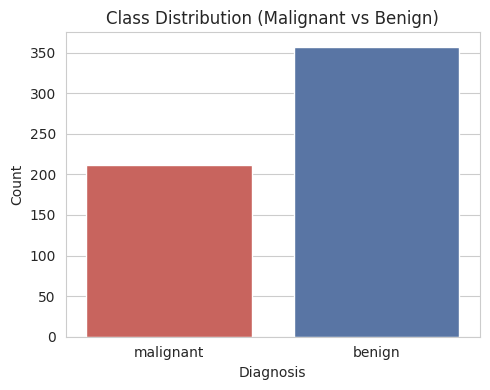

Train shape: (455, 30)  Test shape: (114, 30)
--- Logistic Regression ---
Accuracy:  0.9825
Precision: 0.9861
F1-score:  0.9861
Confusion Matrix:
[[41  1]
 [ 1 71]]

--- Decision Tree ---
Accuracy:  0.9123
Precision: 0.9559
F1-score:  0.9286
Confusion Matrix:
[[39  3]
 [ 7 65]]

--- Random Forest ---
Accuracy:  0.9561
Precision: 0.9589
F1-score:  0.9655
Confusion Matrix:
[[39  3]
 [ 2 70]]



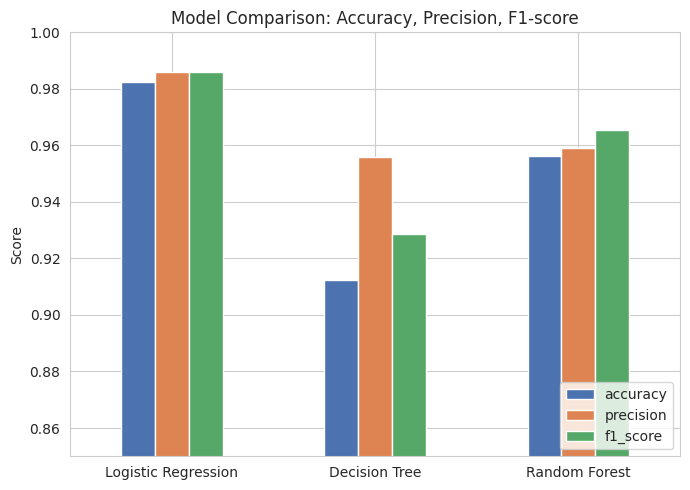

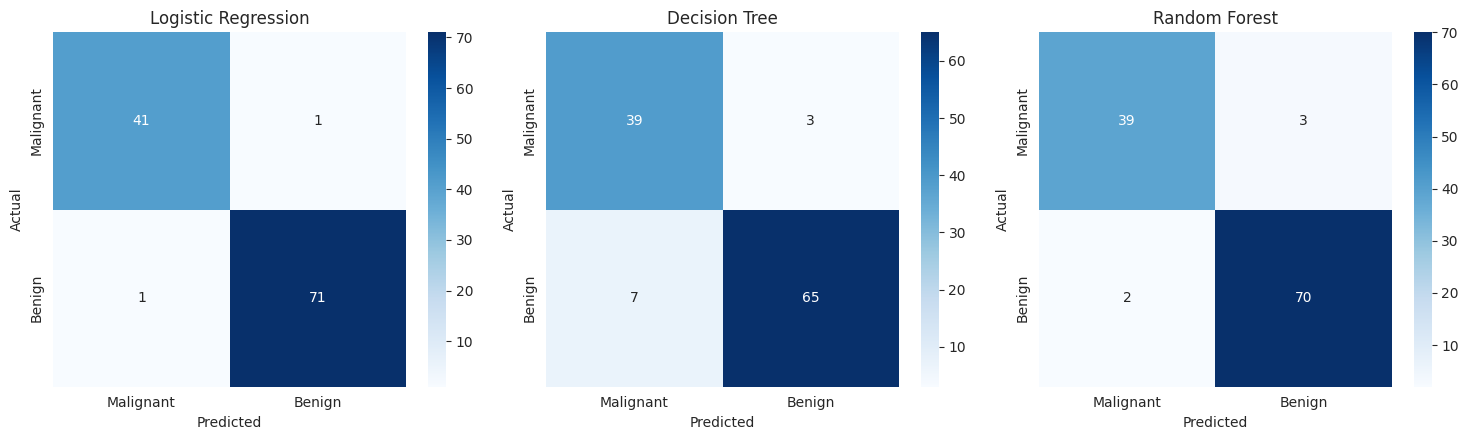

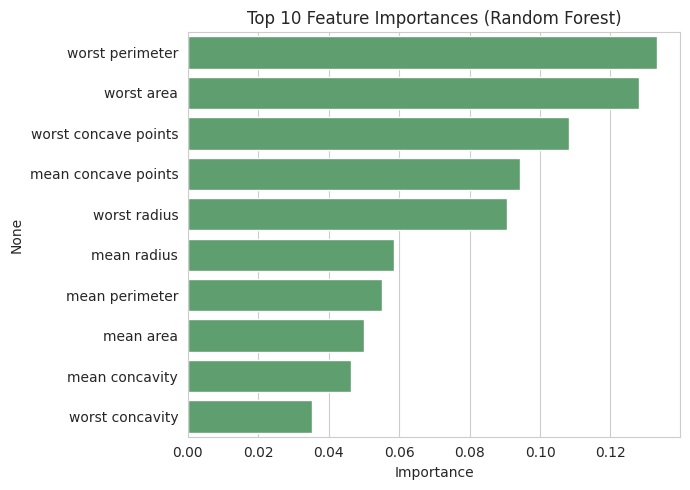

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#task 1
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Number of missing values:", df.isnull().sum().sum())

df.head()

df.info()
plt.figure(figsize=(5,4))
sns.countplot(x=df['target_name'], hue=df['target_name'], palette=["#d9544d", "#4c72b0"], legend=False)
plt.title("Class Distribution (Malignant vs Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#task 2
# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# Encode categorical feature (diagnosis label)
le = LabelEncoder()
df['target_name_encoded'] = le.fit_transform(df['target_name'])

X = data.data
y = data.target  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

#task 3
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
preds = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    preds[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {"accuracy": acc, "precision": prec, "f1_score": f1, "confusion_matrix": cm}
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()
   
    #task 4
    metrics_df = pd.DataFrame({k: {m: v[m] for m in ['accuracy','precision','f1_score']} for k,v in results.items()}).T
metrics_df
metrics_df.plot(kind='bar', figsize=(7,5), color=["#4c72b0","#dd8452","#55a868"])
plt.title("Model Comparison: Accuracy, Precision, F1-score")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, (name, model) in zip(axes, models.items()):
    cm = results[name]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant','Benign'], yticklabels=['Malignant','Benign'])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=data.feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, color="#55a868")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()